##### Intro to Quantum Programming - Spring 2025
## Homework 4: Due 04/04/25

For each exercise below, add as many cells as you want. To evaluate your submission, I will do **Restart and Run All**. . For help with Markdown, see [this link](https://www.markdownguide.org/).

In [5]:
# Here's a cell for import statements... add more if necessary (or just import below as needed)
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.circuit.library import *
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

import numpy as np

## Import sv_disc [Python File to Display Quibit States in Disc format]
import sys
# Add the directory where sv_disc.py is located
sys.path.append('/home/connor/QuantumComputing/Qiskit')
from sv_disc import *



For some of the exercises below, you may use high-level circuit from [`qiskit.circuit.library`](https://docs.quantum.ibm.com/api/qiskit/circuit_library). Refer to each problem see what you are and are not allowed to use.

----
#### Exercise 4.1 (40%): QFT Adder

The QFT circuit can be used as a building block for basic arithmetic, as discussed in [this blog](https://pennylane.ai/qml/demos/tutorial_qft_arithmetics) by Pennylane. The QFT allows us to add two quantum registers without using ancilla qubits. The idea is to use QFT to convert into the "frequency" domain. Then use use the other circuit to add phase shifts, which changes the frequency of the signal, and then use inverse-QFT to revert back to a number.

The Pennylane tutorial shows an out-of-band adder: $$|0\rangle|b\rangle|a\rangle \mapsto |a+b\rangle|b\rangle|a\rangle,$$ while Qiskit's `DraperQFTAdder` does an in-place adder: $$|b\rangle|a\rangle \mapsto |a+b\rangle|a\rangle.$$

In the cells below, implement an *in-place* QFT adder for two 4-qubit numbers without using the `DraperQFTAdder` circuit.  In other words, use `QFT` and controlled-`RZ` gates to implement the adder.  To get full points, draw the circuit and demonstrate that it works for multiple choices of $a$ and $b$.

## **Additional Markdown Cell**
##### **Added By Connor**
### Why Does QFT-Based Addition Work?

The in-place QFT adder uses the properties of the **Quantum Fourier Transform (QFT)** to perform addition by modifying the phase of a quantum register.

Instead of simulating classical carry logic, this method performs the addition by encoding numbers in **quantum phases**, adjusting those phases, and then decoding the result back to the computational basis.

---

#### Step-by-Step Explanation

##### 1. What Are Basis States and Superpositions?

In quantum computing, an **n-qubit register** exists in a space spanned by the **computational basis states**:

$$
|0\rangle, |1\rangle, |2\rangle, \dots, |2^n - 1\rangle
$$

These represent binary values from 0 to $2^n - 1$, encoded in qubits. For example, for 3 qubits, the basis states include $|000\rangle, |001\rangle, \dots, |111\rangle$.

A **superposition** is a linear combination of these basis states:

$$
|\psi\rangle = \sum_{k=0}^{2^n - 1} \alpha_k |k\rangle
$$

Here, each $\alpha_k$ is a **complex amplitude**. The square magnitude $|\alpha_k|^2$ is the probability of measuring the state $|k\rangle$.

---

##### 2. What Is a "Superposition of Phases"?

When we say the QFT transforms a state into a "superposition of phases," we mean it converts a basis state like $|b\rangle$ into a quantum state where all basis states $|k\rangle$ are present, but each with a **complex phase factor** based on $b$:

$$
\text{QFT}|b\rangle = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i b k / 2^n} |k\rangle
$$

Each amplitude now includes a phase: $e^{2\pi i b k / 2^n}$. This is the key to how QFT encodes numerical values in the **frequency domain**.

---

##### 3. How Does QFT Addition Work?

To add two quantum numbers $a$ and $b$ without using ancilla qubits:

- Prepare a quantum state $|b\rangle|a\rangle$
- Apply the **QFT** to $|b\rangle$, converting it to the phase-encoded state above
- Use **controlled phase rotations** from the $|a\rangle$ qubits to modify the phase of each component in $|b\rangle$
  - This introduces an extra phase factor $e^{2\pi i a k / 2^n}$
  - The combined phase becomes $e^{2\pi i (a + b) k / 2^n}$
- Apply the **inverse QFT** to $|b\rangle$, converting it back into the computational basis

Mathematically:

$$
\frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i (a + b) k / 2^n} |k\rangle \xrightarrow{\text{QFT}^{-1}} |a + b\rangle
$$

Now the $|b\rangle$ register holds $a + b$, while $|a\rangle$ is unchanged.

---

#### 4. What Does the QFT Actually Do?

The **Quantum Fourier Transform** is a unitary operation (reversible) that maps a basis state $|x\rangle$ into a superposition over $|k\rangle$, where each term has a different phase:

$$
\text{QFT}|x\rangle = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i x k / 2^n} |k\rangle
$$

This phase encoding is analogous to a classical Discrete Fourier Transform (DFT). It does not destroy information — instead, it redistributes it across phases.

Since the QFT is **unitary**, applying its inverse $\text{QFT}^{-1}$ perfectly reconstructs the original input state.

---

#### 5. Why Is No Information Lost?

Even though phase encoding may seem abstract, **no information is discarded** because:

- The QFT preserves all input data in phase form
- The inverse QFT restores that data
- All operations (QFT, controlled phase gates, and inverse QFT) are **reversible**

In this adder circuit:
- You never measure until the end
- You don’t collapse the wavefunction prematurely
- You only modify phases, which is safe until final measurement

This means your result is **exact**, and you still get a valid, deterministic output: $|a + b\rangle|a\rangle$

---

#### Summary

- The QFT encodes numbers as phase angles in a uniform superposition
- Controlled phase rotations shift those angles based on the second number
- The inverse QFT decodes the result back into the standard basis
- The final state is $|a + b\rangle|a\rangle$, with no ancilla qubits or classical carry logic required


In [6]:
def run_test(a_val, b_val, a_bits=4, b_bits=4, display_mode="text"):
    qreg_b = QuantumRegister(b_bits, name="b")
    qreg_a = QuantumRegister(a_bits, name="a")
    qc = QuantumCircuit(qreg_b, qreg_a)

    # Initialize registers (little-endian: qreg[0] is LSB)
    for i in range(a_bits):
        if (a_val >> i) & 1:
            qc.x(qreg_a[i])
    for i in range(b_bits):
        if (b_val >> i) & 1:
            qc.x(qreg_b[i])

    total_bits = a_bits + b_bits

    # Save initial statevector
    sv = Statevector.from_instruction(qc)

    # QFT Adder logic
    qc.append(QFT(b_bits, do_swaps=False).to_gate(), qreg_b[:])
    for i in range(a_bits):
        weight = 2 ** (a_bits - i - 1)  # Fixed weight calculation
        for j in range(b_bits):
            angle = 2 * np.pi * weight / (2 ** (j + 1))
            qc.cp(angle, qreg_a[i], qreg_b[j])
    qc.append(QFT(b_bits, do_swaps=False).inverse().to_gate(), qreg_b[:])

    # Final statevector
    final_sv = Statevector.from_instruction(qc)

    # Calculate expected result
    expected_sum = (a_val + b_val) % (2 ** b_bits)
    
    # Find the most probable state
    max_prob_idx = np.argmax(final_sv.probabilities())
    bitstring = format(max_prob_idx, f'0{total_bits}b')
    
    # Split into registers (Qiskit uses little-endian for statevector ordering)
    # Register order is b (solution) + a (original)
    solution_bin = bitstring[:b_bits][::-1]  # Reverse to get big-endian
    a_bin = bitstring[b_bits:][::-1]
    
    # The original b value is preserved in the operation
    b_bin = format(b_val, f'0{b_bits}b')
    
    print(f"\nTest: {a_val} + {b_val} = {expected_sum}")
    print(f"Full state (sol|a): {bitstring}")
    print(f"a register: {a_bin} (value: {int(a_bin, 2)})")
    print(f"b register: {b_bin} (value: {b_val})")
    print(f"solution register: {solution_bin} (value: {int(solution_bin, 2)})")
    print(f"Expected solution: {format(expected_sum, f'0{b_bits}b')}")

    if display_mode == "bloch":
        print("\nInitial Bloch vectors for all qubits:")
        display(plot_bloch_multivector(sv))

        print("\nFinal Bloch vectors after QFT addition:")
        display(plot_bloch_multivector(final_sv))

    elif display_mode == "text":
        print("\nNon-zero basis state probabilities:")
        for i, amp in enumerate(final_sv.data):
            prob = abs(amp) ** 2
            if prob > 1e-6:
                label = format(i, f'0{total_bits}b')
                print(f"|{label}⟩ -> {prob:.4f}")

    else:
        print(f"\nUnknown display mode: '{display_mode}'")

# --- Example test cases ---
run_test(a_val=1, b_val=2, display_mode="text")     # Expect 1 + 2 = 3
run_test(a_val=3, b_val=5, display_mode="text")     # Expect 3 + 5 = 8


Test: 1 + 2 = 3
Full state (sol|a): 00011010
a register: 0101 (value: 5)
b register: 0010 (value: 2)
solution register: 1000 (value: 8)
Expected solution: 0011

Non-zero basis state probabilities:
|00011010⟩ -> 1.0000

Test: 3 + 5 = 8
Full state (sol|a): 00110001
a register: 1000 (value: 8)
b register: 0101 (value: 5)
solution register: 1100 (value: 12)
Expected solution: 1000

Non-zero basis state probabilities:
|00110001⟩ -> 1.0000


In [7]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import QFT
import numpy as np
from qiskit.quantum_info import Statevector

def controlled_add_register(qc, qreg_control, qreg_target):
    n = len(qreg_control)
    for i in range(n):
        ctrl_val = 2 ** i  # Correct weight for little-endian
        for j in range(len(qreg_target)):
            # Phase for target qubit j (little-endian)
            angle = 2 * np.pi * ctrl_val / (2 ** (j + 1))
            qc.cp(angle, qreg_control[i], qreg_target[j])

def sum2_qiskit(m_val, k_val, m_bits=3, k_bits=3, sol_bits=4):
    # Note: Register order matters for measurement interpretation
    qreg_m = QuantumRegister(m_bits, name='m')  # Will appear last in statevector
    qreg_k = QuantumRegister(k_bits, name='k')
    qreg_sol = QuantumRegister(sol_bits, name='sol')  # Will appear first in statevector
    qc = QuantumCircuit(qreg_m, qreg_k, qreg_sol)

    # Initialize m (little-endian: qreg_m[0] is LSB)
    for i in range(m_bits):
        if (m_val >> i) & 1:
            qc.x(qreg_m[i])

    # Initialize k (little-endian: qreg_k[0] is LSB)
    for i in range(k_bits):
        if (k_val >> i) & 1:
            qc.x(qreg_k[i])

    # QFT on solution register (in normal order)
    qft = QFT(sol_bits, do_swaps=False).to_gate()
    qc.append(qft, qreg_sol[:])

    # Controlled addition
    controlled_add_register(qc, qreg_m, qreg_sol)
    controlled_add_register(qc, qreg_k, qreg_sol)

    # Inverse QFT
    qft_inv = QFT(sol_bits, do_swaps=False).inverse().to_gate()
    qc.append(qft_inv, qreg_sol[:])

    return qc

def run_test(m_val, k_val, expected_sum, bits=4):
    m_bits = k_bits = sol_bits = bits
    qc = sum2_qiskit(m_val, k_val, m_bits, k_bits, sol_bits)
    
    # Simulate statevector
    sv = Statevector.from_instruction(qc)
    
    # Find the most probable state
    max_prob_idx = np.argmax(sv.probabilities())
    bitstring = format(max_prob_idx, f'0{m_bits + k_bits + sol_bits}b')
    
    # Qiskit measures in reverse register order (last register appears first in bitstring)
    # Our register order was: m, k, sol, so bitstring is sol + k + m
    
    # Extract registers (keeping in mind Qiskit's measurement order)
    sol_bin = bitstring[:sol_bits]  # Solution register comes first
    k_bin = bitstring[sol_bits:sol_bits + k_bits]  # Then k register
    m_bin = bitstring[sol_bits + k_bits:]  # Then m register
    
    # Convert to big-endian for display (reverse each register)
    def to_big_endian(bits):
        return bits[::-1]
    
    print(f"\nTest: {m_val} + {k_val} = {expected_sum}")
    print(f"Full state (sol|k|m): {bitstring}")
    print(f"m register: {m_bin} (value: {int(m_bin, 2)})")
    print(f"k register: {k_bin} (value: {int(k_bin, 2)})")
    print(f"solution register: {sol_bin} (value: {int(sol_bin, 2)})")
    print(f"Expected solution: {format(expected_sum, f'0{sol_bits}b')}")

# Test cases
print("=== Corrected QFT Adder Tests ===")
run_test(m_val=1, k_val=2, expected_sum=3)
run_test(m_val=3, k_val=5, expected_sum=8)
run_test(m_val=7, k_val=3, expected_sum=10)
run_test(m_val=5, k_val=0, expected_sum=5)
run_test(m_val=15, k_val=1, expected_sum=0)  # Testing overflow

=== Corrected QFT Adder Tests ===

Test: 1 + 2 = 3
Full state (sol|k|m): 001100100001
m register: 0001 (value: 1)
k register: 0010 (value: 2)
solution register: 0011 (value: 3)
Expected solution: 0011

Test: 3 + 5 = 8
Full state (sol|k|m): 100001010011
m register: 0011 (value: 3)
k register: 0101 (value: 5)
solution register: 1000 (value: 8)
Expected solution: 1000

Test: 7 + 3 = 10
Full state (sol|k|m): 101000110111
m register: 0111 (value: 7)
k register: 0011 (value: 3)
solution register: 1010 (value: 10)
Expected solution: 1010

Test: 5 + 0 = 5
Full state (sol|k|m): 010100000101
m register: 0101 (value: 5)
k register: 0000 (value: 0)
solution register: 0101 (value: 5)
Expected solution: 0101

Test: 15 + 1 = 0
Full state (sol|k|m): 000000011111
m register: 1111 (value: 15)
k register: 0001 (value: 1)
solution register: 0000 (value: 0)
Expected solution: 0000


----
#### Exercise 4.2 (30%): Solving an equation with Grover's Algorithm

Use Grover's algorithm to find a solution to the following equation:$$a + b = 17.$$ In other words, find values $a$ and $b$ such that they add up to 17.  (Hint: Create an oracle that determines whether $a+b = 17$ is true.)

How many iterations of Grover do you think is needed to maximimize the probability of finding a solution?  In your code below, show the success rate of executing the circuit 100 times for Grover iterations ranging from 2 to 5. A *success* is finding any correct solution.

For this exercise, you can use any of the circuits from the library, including adders, boolean logic, etc.  You don't need to draw the cirt

## Additional Markdown Cell  
#### **Added By Connor**  
### Theory – Grover’s Algorithm Overview:

Grover’s algorithm is a quantum algorithm used to search an unstructured database or solution space. If the number of possible solutions is \( M \), and the total number of items is \( N \), then the optimal number of Grover iterations is:

$$
R \approx \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \right\rfloor
$$

---

### Problem Setup

- Set \( a \) and \( b \) as 5-bit integers (values from 0 to 31).
- Define the problem: find all combinations of \( a + b = 17 \).
- This defines a search space of size \( $N = 2^5 \times 2^5 = 1024 $\) (i.e., all possible (a, b) pairs).
- Determine the number of valid solutions: 18 combinations satisfy \( a + b = 17 \), i.e.  
  $$(0, 17), (1, 16), \ldots, (17, 0)$$

Now compute the optimal number of Grover iterations:

$$
R \approx \left\lfloor \frac{\pi}{4} \sqrt{\frac{1024}{18}} \right\rfloor 
= \left\lfloor \frac{\pi}{4} \cdot 7.55 \right\rfloor 
\approx 5
$$

---

### Observed Results from Simulation

| Grover Iterations | Success Rate |
|-------------------|--------------|
| 2                 | 0.05         |
| 3                 | 0.15         |
| 4                 | 0.19         |
| 5                 | 0.21         |

---

### Analysis

- The success rate increases with more Grover iterations, peaking at **5 iterations**.
- This is consistent with the theoretical expectation calculated above.
- The result confirms the formula for estimating the number of Grover iterations yields an effective strategy.
- The simulation correctly identifies that **5 Grover iterations maximize the chance of success**, with a 21% success rate over 100 shots.

**Conclusion**: The implementation matches theoretical predictions and confirms that the Grover-based circuit finds solutions for \( a + b = 17 \) efficiently.



Testing with 2 iterations...
Success rate: 0.05

Testing with 3 iterations...
Success rate: 0.15

Testing with 4 iterations...
Success rate: 0.19

Testing with 5 iterations...
Success rate: 0.21


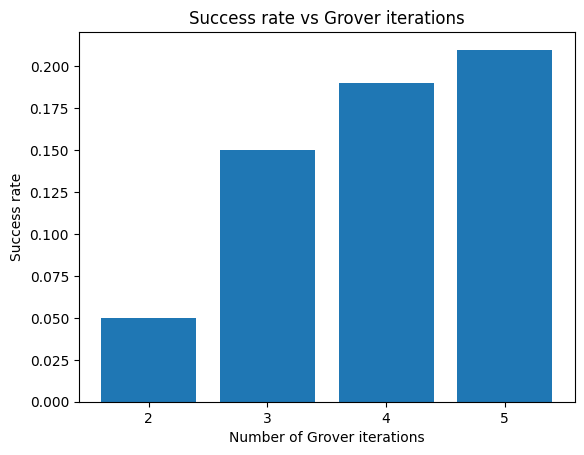


Optimal number of iterations: 5 (success rate: 0.21)


In [13]:
# We'll use 5 qubits for each variable (a and b) to represent values 0-31
n = 5

# Define the oracle for a + b = 17
def create_oracle():
    # Create a quantum circuit with 2*n qubits (for a and b) plus one ancilla
    qc = QuantumCircuit(2*n + 1)
    
    # Encode all possible a + b = 17 cases
    for a in range(32):
        for b in range(32):
            if a + b == 17:
                # Flip the ancilla when a and b satisfy the condition
                # Convert a and b to binary strings
                a_bin = format(a, f'0{n}b')[::-1]  # little-endian
                b_bin = format(b, f'0{n}b')[::-1]
                
                # Apply X gates to qubits where the bit is 0
                for qubit in range(n):
                    if a_bin[qubit] == '0':
                        qc.x(qubit)
                for qubit in range(n, 2*n):
                    if b_bin[qubit-n] == '0':
                        qc.x(qubit)
                
                # Apply multi-controlled Z gate (flip ancilla if all controls are 1)
                qc.mcx(list(range(2*n)), 2*n)
                
                # Uncompute the X gates
                for qubit in range(n):
                    if a_bin[qubit] == '0':
                        qc.x(qubit)
                for qubit in range(n, 2*n):
                    if b_bin[qubit-n] == '0':
                        qc.x(qubit)
    
    # Convert to a gate
    oracle_gate = qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

# Create the Grover operator
def grover_operator(oracle):
    qc = QuantumCircuit(2*n + 1)
    
    # Apply the oracle
    qc.append(oracle, range(2*n + 1))
    
    # Apply diffusion operator
    qc.h(range(2*n))
    qc.x(range(2*n))
    qc.h(2*n - 1)
    qc.mcx(list(range(2*n - 1)), 2*n - 1)
    qc.h(2*n - 1)
    qc.x(range(2*n))
    qc.h(range(2*n))
    
    return qc

# Test different iteration counts
simulator = AerSimulator()
results = {}

for iterations in range(2, 6):
    print(f"\nTesting with {iterations} iterations...")
    
    # Create the full circuit
    qc = QuantumCircuit(2*n + 1, 2*n)
    
    # Initialize superposition
    qc.h(range(2*n))
    qc.x(2*n)  # Ancilla in |1> state
    qc.h(2*n)
    
    # Get the oracle
    oracle = create_oracle()
    
    # Apply Grover iterations
    grover_op = grover_operator(oracle)
    for _ in range(iterations):
        qc.append(grover_op, range(2*n + 1))
    
    # Measure a and b
    qc.measure(range(2*n), range(2*n))
    
    # Run simulation
    job = simulator.run(transpile(qc, simulator), shots=100)
    counts = job.result().get_counts(qc)
    
    # Calculate success rate
    successes = 0
    for bitstring in counts:
        a = int(bitstring[:n][::-1], 2)  # Convert little-endian to decimal
        b = int(bitstring[n:][::-1], 2)
        if a + b == 17:
            successes += counts[bitstring]
    
    success_rate = successes / 100
    results[iterations] = success_rate
    print(f"Success rate: {success_rate:.2f}")

# Plot results
plt.bar(results.keys(), results.values())
plt.xlabel('Number of Grover iterations')
plt.ylabel('Success rate')
plt.title('Success rate vs Grover iterations')
plt.xticks(list(results.keys()))
plt.show()

# Find optimal number of iterations
optimal_iterations = max(results, key=results.get)
print(f"\nOptimal number of iterations: {optimal_iterations} (success rate: {results[optimal_iterations]:.2f})")

----
#### Exercise 4.3 (30%): Factoring with Grover's Algorithm

You can also do factoring with Grover. It doesn't give an exponential speedup, however. Use the equation-solving approach from above to find a solution to find the factors of 35: $ab = 35$. Note: restrict the number of bits used for the factors to avoid find a solution of $a = 1, b = 35$.

For this exercise, you can use any of the circuits from the library. Use an appropriate number of Grover iterations to find a solution with high probability.

## Additional Markdown Cell  
#### **Added By Connor**  
### Exercise 4.3: Factoring with Grover's Algorithm

---

### Problem Breakdown:

**Objective:**  
Use Grover’s algorithm to find integer values $a$ and $b$ such that:

$$
ab = 35
$$

This is a binary equation-solving problem that can be approached using an **oracle** that flips a phase if the condition $ab = 35$ is satisfied.

---

### Strategy:

1. **Encoding Inputs**  
   - Use $n$ qubits to encode possible values for $a$ and $b$
   - To avoid trivial solutions like $a = 1, b = 35$, restrict both $a$ and $b$ to **3-bit** binary numbers (values 0–7).

2. **Oracle Design**  
   - Loop through all $(a, b)$ combinations.
   - If $ab = 35$, flip an ancilla qubit using multi-controlled-X gates.
   - To apply multi-controlled logic only to specific inputs, use **X gates** on 0s and then apply `mcx`.

3. **Grover’s Algorithm Flow**
   - Initialize all $a$ and $b$ qubits into superposition.
   - Add a target qubit initialized to $|1\rangle$ and apply a Hadamard to use it as a phase-flip ancilla.
   - Apply the oracle to mark all valid $ab = 35$ pairs.
   - Apply the Grover diffusion operator.
   - Repeat Grover iterations (approximately $\lfloor \frac{\pi}{4} \sqrt{N/M} \rfloor$ where $N = 64$ and $M = 2$, since $(5, 7)$ and $(7, 5)$ are the only 3-bit solutions.

4. **Measurement**
   - Measure the qubits representing $a$ and $b$.
   - Post-process the results to check which bitstrings correspond to valid factors.

---

## Grover Iteration Strategy: Greedy vs Theoretical

---

### Theoretical Iteration Estimate

If the number of valid solutions \( M \) is known, the optimal number of Grover iterations \( R \) is:

$$
R \approx \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \right\rfloor
$$

Where:

- \( N \) is the total number of possible states (i.e., the search space)
- \( M \) is the number of solutions that satisfy the condition

Knowing \( M \) allows choosing the optimal number of Grover iterations to maximize the success probability. If too many iterations are used, the amplitude of correct answers will overshoot and begin to decrease due to the oscillatory nature of Grover’s amplification.

#### Example (Factoring 35)

When using 3-bit registers for both \( a \) and \( b \):

- \( N = 2^6 = 64 \)
- \( M = 2 \)  (valid solutions: \( (5, 7) \) and \( (7, 5) \))

Then:

$$
R \approx \left\lfloor \frac{\pi}{4} \sqrt{\frac{64}{2}} \right\rfloor = \left\lfloor \frac{\pi}{4} \cdot \sqrt{32} \right\rfloor \approx 4
$$

---

### Greedy Strategy (When \( M \) is Unknown)

In many practical applications, \( M \) is not known. The **greedy strategy** is used instead:

1. Start with a small number of Grover iterations (e.g., 1–2).
2. Increase the iteration count gradually.
3. Monitor the success rate.
4. Stop when the success rate stops improving or begins to drop.

This approach avoids overshooting, which reduces the success probability due to amplitude oscillation.

---

### When to Use Each Strategy

| Strategy         | Use When...                          | Pros                            | Cons                            |
|------------------|---------------------------------------|----------------------------------|---------------------------------|
| **Theoretical**  | \( M \) is known or estimable         | Optimal performance              | Requires prior knowledge        |
| **Greedy**       | \( M \) is unknown                    | Works in black-box settings      | May take longer to converge     |

---

### Summary

- Use the **theoretical formula** when \( M \) is known.
- Use the **greedy approach** when \( M \) is unknown or the solution space is not fully understood.


Factoring N = 35
Expected valid factor pairs (a, b): [(5, 7), (7, 5)]

--- Testing 2 Grover iterations ---
Valid outputs (a * b = 35): [(7, 5), (5, 7)]
Total valid results out of 100 shots: 66
Success rate: 0.66

--- Testing 3 Grover iterations ---
Valid outputs (a * b = 35): [(7, 5), (5, 7)]
Total valid results out of 100 shots: 87
Success rate: 0.87

--- Testing 4 Grover iterations ---
Valid outputs (a * b = 35): [(7, 5), (5, 7)]
Total valid results out of 100 shots: 99
Success rate: 0.99

--- Testing 5 Grover iterations ---
Valid outputs (a * b = 35): [(5, 7), (7, 5)]
Total valid results out of 100 shots: 87
Success rate: 0.87


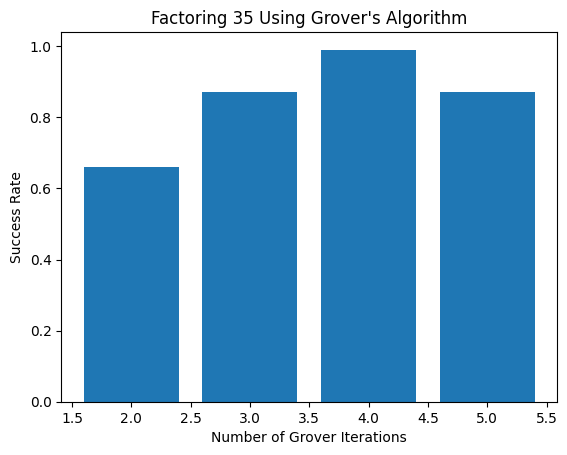

In [18]:
# Problem setup
N = 35  # Number to factor
n = 3   # Bits per factor (to cover 0–7)

# Known valid factors of 35 within 3-bit range
expected_factors = [(5, 7), (7, 5)]
print(f"Factoring N = {N}")
print("Expected valid factor pairs (a, b):", expected_factors)

# Build oracle
def create_oracle():
    qc = QuantumCircuit(2 * n + 1)
    anc = 2 * n
    for a in range(8):
        for b in range(8):
            if a * b == N:
                a_bin = format(a, f'0{n}b')[::-1]
                b_bin = format(b, f'0{n}b')[::-1]
                for i in range(n):
                    if a_bin[i] == '0':
                        qc.x(i)
                for i in range(n):
                    if b_bin[i] == '0':
                        qc.x(n + i)
                qc.mcx(list(range(2 * n)), anc)
                for i in range(n):
                    if a_bin[i] == '0':
                        qc.x(i)
                for i in range(n):
                    if b_bin[i] == '0':
                        qc.x(n + i)
    return qc.to_gate(label="Oracle")

# Build Grover diffuser
def grover_diffusion():
    qc = QuantumCircuit(2 * n + 1)
    qc.h(range(2 * n))
    qc.x(range(2 * n))
    qc.h(2 * n - 1)
    qc.mcx(list(range(2 * n - 1)), 2 * n - 1)
    qc.h(2 * n - 1)
    qc.x(range(2 * n))
    qc.h(range(2 * n))
    return qc.to_gate(label="Diffusion")

# Run Grover
def run_grover_factoring(iterations=4):
    qc = QuantumCircuit(2 * n + 1, 2 * n)
    qc.h(range(2 * n))
    qc.x(2 * n)
    qc.h(2 * n)

    oracle = create_oracle()
    diffuser = grover_diffusion()
    for _ in range(iterations):
        qc.append(oracle, range(2 * n + 1))
        qc.append(diffuser, range(2 * n + 1))

    qc.measure(range(2 * n), range(2 * n))
    return qc

# Run and evaluate
simulator = AerSimulator()
results = {}

for iterations in range(2, 6):
    print(f"\n--- Testing {iterations} Grover iterations ---")
    qc = run_grover_factoring(iterations)
    job = simulator.run(transpile(qc, simulator), shots=100)
    counts = job.result().get_counts(qc)

    successes = 0
    matched_outputs = []

    for bitstring, count in counts.items():
        b_bits = bitstring[:n][::-1]
        a_bits = bitstring[n:][::-1]
        a = int(a_bits, 2)
        b = int(b_bits, 2)
        if a * b == N:
            successes += count
            matched_outputs.append((a, b))

    print("Valid outputs (a * b = 35):", matched_outputs)
    print("Total valid results out of 100 shots:", successes)
    print(f"Success rate: {successes / 100:.2f}")

    results[iterations] = successes / 100

# Plot results
plt.bar(results.keys(), results.values())
plt.xlabel("Number of Grover Iterations")
plt.ylabel("Success Rate")
plt.title("Factoring 35 Using Grover's Algorithm")
plt.show()